# Testing the FOLDE Module Machinery

This notebook tests the functionality of the FOLDE (Few-shot and zerO-shot Learning for protein Design and Engineering) module, particularly focusing on the data loading functionality.

In [1]:
%load_ext autoreload
%autoreload 2
import sys
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

# Configure logging
import logging
logging.basicConfig(level=logging.INFO, format='%(asctime)s - %(name)s - %(levelname)s - %(message)s')
logger = logging.getLogger()

from folde.data import get_available_proteingym_datasets, get_proteingym_dataset
from folde.campaign import FolDEModelConfig, simulate_campaign

## Importing the FOLDE Module

First, let's try to import our FOLDE module functions.

# Import the FOLDE module
try:
    from folde import get_available_proteingym_datasets, get_proteingym_dataset
    print("Successfully imported the FOLDE module functions!")
except Exception as e:
    print(f"Error importing the FOLDE module: {e}")

In [2]:
# Define paths
from folde.data import MODULE_DIR, DATA_DIR, DMS_DIR, EMBEDDINGS_DIR, NATURALNESS_DIR, DMS_METADATA_FILE

print(f"Module directory: {MODULE_DIR}")
print(f"Data directory: {DATA_DIR}")
print(f"DMS directory: {DMS_DIR}")
print(f"Embeddings directory: {EMBEDDINGS_DIR}")
print(f"Naturalness directory: {NATURALNESS_DIR}")
print(f"DMS metadata file: {DMS_METADATA_FILE}")

Module directory: /Users/jacobroberts/git/foldy/backend/src/folde
Data directory: /Users/jacobroberts/git/foldy/backend/src/folde/data
DMS directory: /Users/jacobroberts/git/foldy/backend/src/folde/data/DMS_ProteinGym_substitutions
Embeddings directory: /Users/jacobroberts/git/foldy/backend/src/folde/data/embeddings
Naturalness directory: /Users/jacobroberts/git/foldy/backend/src/folde/data/naturalness
DMS metadata file: /Users/jacobroberts/git/foldy/backend/src/folde/data/DMS_substitutions.csv


## Testing get_available_proteingym_datasets

Now let's test the `get_available_proteingym_datasets` function with specific embedding and naturalness models.

In [3]:

embedding_model_id = '300m'
naturalness_model_id = '600m'

print(f"Testing with embedding model: {embedding_model_id} and naturalness model: {naturalness_model_id}")
available_datasets = get_available_proteingym_datasets(embedding_model_id, naturalness_model_id)

if not available_datasets.empty:
    print(f"Found {len(available_datasets)} available datasets")
    print("\nSample of available datasets:")
    display(available_datasets.head())
else:
    print("No datasets found with these models")

2025-03-17 12:50:32,034 - folde.data - INFO - Loaded metadata for 217 DMS datasets


2025-03-17 12:50:32,047 - folde.data - INFO - Found 3 datasets with embedding model '300m' and naturalness model '600m'


Testing with embedding model: 300m and naturalness model: 600m
Found 3 available datasets

Sample of available datasets:


,DMS_id,DMS_filename,UniProt_ID,taxon,source_organism,target_seq,seq_len,includes_multiple_mutants,DMS_total_number_mutants,DMS_number_single_mutants,...,raw_DMS_filename,raw_DMS_phenotype_name,raw_DMS_directionality,raw_DMS_mutant_column,weight_file_name,pdb_file,pdb_range,ProteinGym_version,raw_mut_offset,coarse_selection_type
0,A0A140D2T1_ZIKV_Sourisseau_2019,A0A140D2T1_ZIKV_Sourisseau_2019.csv,A0A140D2T1_ZIKV,Virus,Zika virus (ZIKV),MKNPKKKSGGFRIVNMLKRGVARVNPLGGLKRLPAGLLLGHGPIRM...,3423,False,9576,9576,...,A0A140D2T1_ZIKV_Sourisseau_growth_2019.csv,effect,1,mutant,A0A140D2T1_ZIKV_theta_0.01.npy,A0A140D2T1_ZIKV.pdb,291-794,0.1,NaN,OrganismalFitness
23,BLAT_ECOLX_Stiffler_2015,BLAT_ECOLX_Stiffler_2015.csv,BLAT_ECOLX,Prokaryote,Escherichia coli,MSIQHFRVALIPFFAAFCLPVFAHPETLVKVKDAEDQLGARVGYIE...,286,False,4996,4996,...,BLAT_ECOLX_Stiffler_2015.csv,2500,1,mutant,BLAT_ECOLX_theta_0.2.npy,BLAT_ECOLX.pdb,1-286,0.1,NaN,OrganismalFitness
124,PHOT_CHLRE_Chen_2023,PHOT_CHLRE_Chen_2023.csv,PHOT_CHLRE,Eukaryote,Chlamydomonas reinhardtii,AGLRHTFVVADATLPDCPLVYASEGFYAMTGYGPDEVLGHNARFLQ...,118,True,167529,2122,...,sb2c00662_si_001.xlsx,mean,1,mutant,PHOT_CHLRE_theta0.2_2023-08-07_b02.npy,PHOT_CHLRE.pdb,1-118,1.0,NaN,Activity


In [4]:
dms_id = available_datasets['DMS_id'].iloc[0]
    
print(f"Testing with dataset: {dms_id}, embedding model: {embedding_model_id}, naturalness model: {naturalness_model_id}")

try:
    naturalness_df, embedding_df, activity_df = get_proteingym_dataset(dms_id, embedding_model_id, naturalness_model_id)
    print(f"Successfully loaded datasets:")
    print(f"  - Naturalness data: {len(naturalness_df)} rows")
    print(f"  - Embedding data: {len(embedding_df)} rows")
    print(f"  - Activity data: {len(activity_df)} rows")
    
    # Display dataset summaries
    print("\nNaturalness DataFrame columns:")
    print(naturalness_df.columns.tolist())
    
    print("\nEmbedding DataFrame columns:")
    print(embedding_df.columns.tolist())
    
    print("\nActivity DataFrame columns:")
    print(activity_df.columns.tolist())
    
    # Display sample of each dataframe
    print("\nSample of naturalness data:")
    display(naturalness_df.head())
    
    print("\nSample of activity data:")
    display(activity_df.head())
    
    # Check embedding format
    print("\nEmbedding format:")
    embedding = embedding_df['embedding'].iloc[0]
    print(f"Type: {type(embedding)}")
    print(f"Shape: {embedding.shape if hasattr(embedding, 'shape') else 'N/A'}")
    print(f"First 5 values: {embedding[:5] if hasattr(embedding, '__getitem__') else 'N/A'}")
    
    # Check seq_id format in all dataframes
    print("\nSeq_id examples:")
    print(f"Naturalness first seq_id: {naturalness_df['seq_id'].iloc[0] if 'seq_id' in naturalness_df.columns else 'N/A'}")
    print(f"Embedding first seq_id: {embedding_df['seq_id'].iloc[0] if 'seq_id' in embedding_df.columns else 'N/A'}")
    print(f"Activity first seq_id: {activity_df['seq_id'].iloc[0] if 'seq_id' in activity_df.columns else 'N/A'}")
    
except Exception as e:
    print(f"Error loading dataset: {e}")
    raise e

Testing with dataset: A0A140D2T1_ZIKV_Sourisseau_2019, embedding model: 300m, naturalness model: 600m


2025-03-17 12:50:32,943 - folde.data - INFO - Loaded activity data for A0A140D2T1_ZIKV_Sourisseau_2019 with 9576 rows
2025-03-17 12:50:34,620 - folde.data - INFO - Loaded embeddings for A0A140D2T1_ZIKV_Sourisseau_2019 with 9577 rows
2025-03-17 12:50:34,642 - folde.data - INFO - Loaded naturalness scores for A0A140D2T1_ZIKV_Sourisseau_2019 with 16632 rows


Successfully loaded datasets:
  - Naturalness data: 9576 rows
  - Embedding data: 9576 rows
  - Activity data: 9576 rows

Naturalness DataFrame columns:
['seq_id', 'probability', 'locus', 'wt_probability', 'wt_marginal']

Embedding DataFrame columns:
['seq_id', 'seq', 'embedding']

Activity DataFrame columns:
['mutant', 'mutated_sequence', 'DMS_score', 'DMS_score_bin', 'seq_id']

Sample of naturalness data:


,seq_id,probability,locus,wt_probability,wt_marginal
seq_id,,,,,
R582E,R582E,0.088379,292,0.053467,1.652968
G417R,G417R,0.031494,127,0.160156,0.196646
T769F,T769F,0.099609,479,0.113281,0.879310
V724P,V724P,0.041748,434,0.211914,0.197005
L666G,L666G,0.021606,376,0.205078,0.105357



Sample of activity data:


,mutant,mutated_sequence,DMS_score,DMS_score_bin,seq_id
seq_id,,,,,
R582E,R582E,MKNPKKKSGGFRIVNMLKRGVARVNPLGGLKRLPAGLLLGHGPIRM...,0.016388,0,R582E
G417R,G417R,MKNPKKKSGGFRIVNMLKRGVARVNPLGGLKRLPAGLLLGHGPIRM...,0.030152,0,G417R
T769F,T769F,MKNPKKKSGGFRIVNMLKRGVARVNPLGGLKRLPAGLLLGHGPIRM...,0.069033,1,T769F
V724P,V724P,MKNPKKKSGGFRIVNMLKRGVARVNPLGGLKRLPAGLLLGHGPIRM...,0.180131,1,V724P
L666G,L666G,MKNPKKKSGGFRIVNMLKRGVARVNPLGGLKRLPAGLLLGHGPIRM...,0.008895,0,L666G



Embedding format:
Type: <class 'numpy.ndarray'>
Shape: (960,)
First 5 values: [-0.00135676 -0.00493268  0.00417653  0.00323149  0.00665843]

Seq_id examples:
Naturalness first seq_id: R582E
Embedding first seq_id: R582E
Activity first seq_id: R582E


# Test out a simulation campaign

In [7]:
import numpy as np

# Example configuration
config_list = [
    FolDEModelConfig(
        name="RandomForest",
        # Required parameters
        naturalness_model_id="600m",  # ESM-2 650M model
        embedding_model_id="300m",  # Same model for embeddings
        zeroshot_model_name="NaturalnessZeroShotModel",
        zeroshot_model_params={
            "transformation": "identity"  # No transformation of naturalness scores
        },
        # Few-shot model configuration (used after first round)
        fewshot_model_name="RandomForestFewShotModel",
        fewshot_model_params={
            "n_estimators": 100,
            "criterion": "friedman_mse",
            "max_depth": None,
            "min_samples_split": 2,
            "min_samples_leaf": 1,
            "min_weight_fraction_leaf": 0.0,
            "max_features": 1.0,
            "max_leaf_nodes": None,
            "min_impurity_decrease": 0.0,
            "bootstrap": True,
            "oob_score": False,
            "n_jobs": None,
            "random_state": 1,
            "verbose": 0,
            "warm_start": False,
            "ccp_alpha": 0.0,
            "max_samples": None,
        },
    ),
    # Another configuration to compare
    FolDEModelConfig(
        name="MLP",
        naturalness_model_id="600m",
        embedding_model_id="300m",
        zeroshot_model_name="NaturalnessZeroShotModel",
        zeroshot_model_params={"distance_metric": "euclidean"},
        fewshot_model_name="MLPFewShotModel",
        fewshot_model_params={
            "random_state": 1,
            "max_iter": 5000,
            "hidden_layer_sizes": (100, 50),
        },
    ),
    # Another configuration to compare
    FolDEModelConfig(
        name="MLP n_iter_no_change100",
        naturalness_model_id="600m",
        embedding_model_id="300m",
        zeroshot_model_name="NaturalnessZeroShotModel",
        zeroshot_model_params={"distance_metric": "euclidean"},
        fewshot_model_name="MLPFewShotModel",
        fewshot_model_params={
            "random_state": 1,
            "max_iter": 5000,
            "hidden_layer_sizes": (100, 50),
            "n_iter_no_change": 100,
        },
    ),
]

# Run the simulation
results = simulate_campaign(
    dms_id="BLAT_ECOLX_Stiffler_2015",  # ProteinGym dataset ID
    # dms_id="PHOT_CHLRE_Chen_2023",  # ProteinGym dataset ID
    # dms_id="A0A140D2T1_ZIKV_Sourisseau_2019",  # ProteinGym dataset ID
    round_size=16,  # Select 10 variants per round
    number_of_simulations=5,  # Run 5 simulations with each config
    config_list=config_list,  # Model configurations to evaluate
    activity_column="DMS_score",  # Column with activity data
    max_rounds=4,  # Run for 5 rounds
    random_seed=42,  # For reproducibility
)

2025-03-17 12:55:20,015 - folde.campaign - INFO - Running simulations for configuration 1/3
2025-03-17 12:55:20,016 - folde.campaign - INFO - Config: name='RandomForest' naturalness_model_id='600m' embedding_model_id='300m' zeroshot_model_name='NaturalnessZeroShotModel' zeroshot_model_params={'transformation': 'identity'} fewshot_model_name='RandomForestFewShotModel' fewshot_model_params={'n_estimators': 100, 'criterion': 'friedman_mse', 'max_depth': None, 'min_samples_split': 2, 'min_samples_leaf': 1, 'min_weight_fraction_leaf': 0.0, 'max_features': 1.0, 'max_leaf_nodes': None, 'min_impurity_decrease': 0.0, 'bootstrap': True, 'oob_score': False, 'n_jobs': None, 'random_state': 1, 'verbose': 0, 'warm_start': False, 'ccp_alpha': 0.0, 'max_samples': None}
2025-03-17 12:55:20,036 - folde.data - INFO - Loaded activity data for BLAT_ECOLX_Stiffler_2015 with 4996 rows
2025-03-17 12:55:20,925 - folde.data - INFO - Loaded embeddings for BLAT_ECOLX_Stiffler_2015 with 5435 rows
2025-03-17 12:55:

# TODO: Fix plotting code...

2025-03-17 12:19:38,789 - matplotlib.category - INFO - Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
2025-03-17 12:19:38,794 - matplotlib.category - INFO - Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
/Users/jacobroberts/miniforge3/envs/esm_jupyter/lib/python3.12/site-packages/seaborn/categorical.py:3399: UserWarning: 9.4% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)
/Users/jacobroberts/miniforge3/envs/esm_jupyter/lib/python3.12/site-packages/seaborn/categorical.py:3399: UserWarning: 11.9% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarn

<Axes: xlabel='round_idx', ylabel='percentile'>

/Users/jacobroberts/miniforge3/envs/esm_jupyter/lib/python3.12/site-packages/seaborn/categorical.py:3399: UserWarning: 10.6% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)
/Users/jacobroberts/miniforge3/envs/esm_jupyter/lib/python3.12/site-packages/seaborn/categorical.py:3399: UserWarning: 14.4% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)


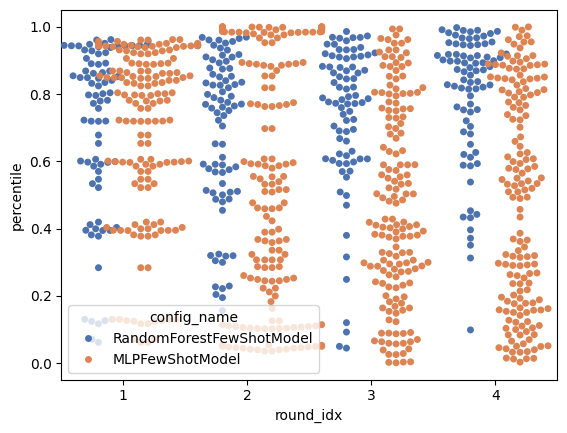

In [13]:
import seaborn as sns

activities_list = []
for config_idx, config_results in enumerate(results.simulation_results):
  config = config_results[0]
  sim_results = config_results[1]

  # config_name = config.zeroshot_model_name + ' → ' + config.fewshot_model_name
  config_name = config.fewshot_model_name

  for sim_idx, sim_result in enumerate(sim_results):
    for round_idx, tested_variant_percentiles in enumerate(sim_result.tested_variant_percentiles):
      for percentile in tested_variant_percentiles:
        activities_list.append({
          'config_name': config_name,
          'sim_idx': sim_idx,
          'round_idx': round_idx + 1,
          'percentile': percentile
        })

activities_df = pd.DataFrame(activities_list)

sns.swarmplot(data=activities_df, x="round_idx", y="percentile", hue="config_name", palette="deep", dodge=True)


/var/folders/p6/jn7zk09154v2f60d993vb2sm0000gn/T/ipykernel_2575/3846258015.py:56: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  sns.lineplot(
/var/folders/p6/jn7zk09154v2f60d993vb2sm0000gn/T/ipykernel_2575/3846258015.py:72: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  sns.lineplot(
/var/folders/p6/jn7zk09154v2f60d993vb2sm0000gn/T/ipykernel_2575/3846258015.py:88: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  sns.lineplot(


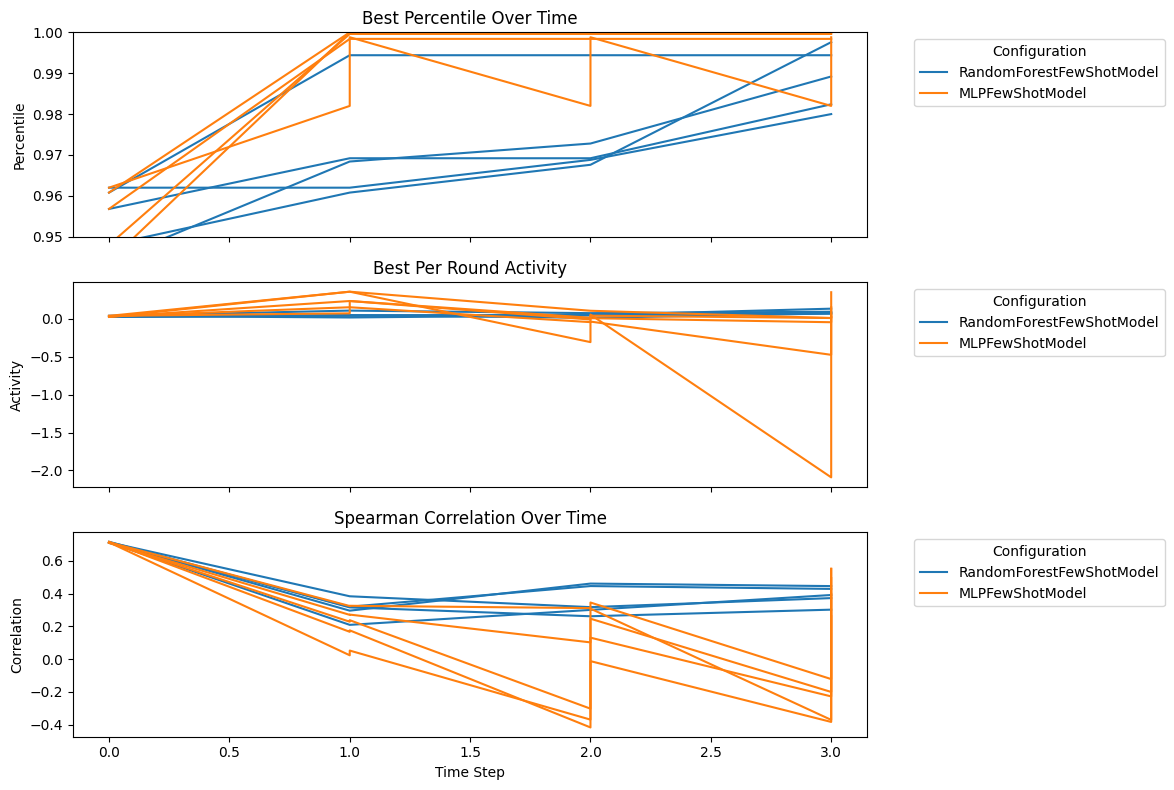

In [14]:
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# First, let's reshape your data into a format suitable for seaborn
data_list = []

# Assuming results['simulation_results'] is your data structure
for config_idx, (model_config, sim_results) in enumerate(results.simulation_results):
    # config_name = results['configurations'][config_idx]['config']['zeroshot_model_name'] + ' → ' + results['configurations'][config_idx]['config']['fewshot_model_name']
    config_name = model_config.fewshot_model_name
    for sim_idx, sim in enumerate(sim_results):
        # Get both metrics for this simulation
        cumulative_best_percentile_list = sim.cumulative_best_percentile
        best_activity_per_round_list = sim.best_activity_per_round
        round_metrics_list = sim.round_metrics
        
        # Add cumulative best percentile data
        for t, activity in enumerate(cumulative_best_percentile_list):
            data_list.append({
                'Time': t,
                'Value': activity,
                'Metric': 'Best Percentile',
                'Config': config_name,  
                'Simulation': sim_idx
            })

        # Add cumulative best percentile data
        for t, activity in enumerate(best_activity_per_round_list):
            data_list.append({
                'Time': t,
                'Value': activity,
                'Metric': 'Best Activity Per Round',
                'Config': config_name,
                'Simulation': sim_idx
            })
        
        # Add Spearman correlation data
        for t, round_metrics in enumerate(round_metrics_list):
            data_list.append({
                'Time': t,
                'Value': round_metrics['whole_dataset_spearman'],
                'Metric': 'Spearman Correlation',
                'Config': config_name,
                'Simulation': sim_idx
            })

# Convert to DataFrame
df_plot = pd.DataFrame(data_list)

# Create figure with subplots
fig, (ax1, ax2, ax3) = plt.subplots(3, 1, figsize=(12, 8), sharex=True)

# Plot Best Percentile
sns.lineplot(
    data=df_plot[df_plot['Metric'] == 'Best Percentile'],
    x='Time',
    y='Value',
    hue='Config',
    units='Simulation',
    estimator=None,
    ci=None,
    ax=ax1
)
ax1.set_ylim(0.95, 1.0)
ax1.set_title('Best Percentile Over Time')
ax1.set_ylabel('Percentile')
ax1.legend(title='Configuration', bbox_to_anchor=(1.05, 1))

# Plot Best Percentile
sns.lineplot(
    data=df_plot[df_plot['Metric'] == 'Best Activity Per Round'],
    x='Time',
    y='Value',
    hue='Config',
    # ci=95,
    units='Simulation',
    estimator=None,
    ci=None,
    ax=ax2
)
ax2.set_title('Best Per Round Activity')
ax2.set_ylabel('Activity')
ax2.legend(title='Configuration', bbox_to_anchor=(1.05, 1))

# Plot Spearman Correlation
sns.lineplot(
    data=df_plot[df_plot['Metric'] == 'Spearman Correlation'],
    x='Time',
    y='Value',
    hue='Config',
    units='Simulation',
    estimator=None,
    ci=None,
    ax=ax3
)
ax3.set_title('Spearman Correlation Over Time')
ax3.set_xlabel('Time Step')
ax3.set_ylabel('Correlation')
ax3.legend(title='Configuration', bbox_to_anchor=(1.05, 1))

# Adjust layout to prevent overlap
plt.tight_layout()
plt.show()

In [3]:
df_plot

NameError: name 'df_plot' is not defined

In [42]:
df_plot

,Time,Activity,Config,Simulation
0,0,NaN,Config 0,0
1,1,NaN,Config 0,0
2,2,NaN,Config 0,0
3,3,NaN,Config 0,0
4,4,NaN,Config 0,0
5,0,NaN,Config 0,1
6,1,NaN,Config 0,1
7,2,NaN,Config 0,1
8,3,NaN,Config 0,1
9,4,NaN,Config 0,1


In [28]:
results['simulation_results'][1]

[{'config': {'naturalness_model_id': '600m',
   'embedding_model_id': '300m',
   'zeroshot_model_name': 'NaturalnessZeroShotModel',
   'zeroshot_model_params': {'distance_metric': 'euclidean'},
   'fewshot_model_name': 'MLPFewShotModel',
   'fewshot_model_params': {'random_state': 1,
    'max_iter': 5000,
    'hidden_layer_sizes': (100, 50)}},
  'rounds': [1, 2, 3, 4, 5],
  'best_variant_per_round': ['S122E', 'K32H', 'R273E', 'G76L', 'H94R'],
  'best_activity_per_round': [0.036991756,
   0.006558769,
   -0.007542683,
   -1.685606461,
   -0.03804817],
  'cumulative_best_activity': [0.036991756,
   0.036991756,
   0.036991756,
   0.036991756,
   0.036991756],
  'tested_variants': [['M180T',
    'M180S',
    'M153I',
    'H151R',
    'M153L',
    'Y44V',
    'Y44A',
    'L199P',
    'F58Y',
    'L196A',
    'N173G',
    'F228W',
    'S264T',
    'P25A',
    'S122E',
    'L196V'],
   ['R81D',
    'L282D',
    'R255Y',
    'G85H',
    'R91Y',
    'G39H',
    'L120D',
    'R273T',
    'R273M

In [16]:
metrics

{'mean_best_activity': 0.154985174,
 'std_best_activity': 0.0,
 'mean_percentile_rank': 99.85988791032825,
 'std_percentile_rank': 0.0,
 'mean_improvement_over_wt': 0.0,
 'std_improvement_over_wt': 0.0,
 'num_simulations': 5}

# If we have datasets, visualize aspects of them
if 'naturalness_df' in locals() and 'embedding_df' in locals() and 'activity_df' in locals():
    # Plot 1: Embedding dimensionality
    plt.figure(figsize=(14, 5))
    plt.subplot(1, 2, 1)
    embedding = embedding_df['embedding'].iloc[0]
    plt.hist(embedding, bins=30, alpha=0.7)
    plt.title(f'Histogram of First Embedding Values\n(dimension={len(embedding) if hasattr(embedding, "__len__") else "unknown"})')
    plt.xlabel('Value')
    plt.ylabel('Frequency')
    
    # Plot 2: Naturalness distribution
    if 'naturalness' in naturalness_df.columns:
        plt.subplot(1, 2, 2)
        plt.hist(naturalness_df['naturalness'], bins=30, alpha=0.7)
        plt.title('Distribution of Naturalness Scores')
        plt.xlabel('Naturalness')
        plt.ylabel('Frequency')
    
    plt.tight_layout()
    plt.show()
    
    # If there is a clear target column for fitness or activity, visualize it
    possible_target_cols = ['fitness', 'score', 'activity', 'DMS_score', 'measurement']
    target_col = None
    
    for col in possible_target_cols:
        if col in activity_df.columns and activity_df[col].dtype in [np.float64, np.int64]:
            target_col = col
            break
    
    if target_col:
        plt.figure(figsize=(14, 5))
        
        # Plot target distribution
        plt.subplot(1, 2, 1)
        plt.hist(activity_df[target_col], bins=30, alpha=0.7)
        plt.title(f'Distribution of {target_col}')
        plt.xlabel(target_col)
        plt.ylabel('Frequency')
        
        # Checking if we can match naturalness data with activity data
        if 'seq_id' in activity_df.columns and 'seq_id' in naturalness_df.columns:
            # Merge datasets for plotting
            merged = activity_df[['seq_id', target_col]].merge(
                naturalness_df[['seq_id', 'naturalness']], on='seq_id', how='inner'
            )
            
            if not merged.empty:
                plt.subplot(1, 2, 2)
                plt.scatter(merged['naturalness'], merged[target_col], alpha=0.5)
                plt.title(f'Naturalness vs {target_col}')
                plt.xlabel('Naturalness')
                plt.ylabel(target_col)
                print(f"Merged {len(merged)} rows with both naturalness and {target_col} data")
            else:
                print("Could not merge naturalness with activity data - no matching seq_ids")
        
        plt.tight_layout()
        plt.show()
else:
    print("No datasets available for visualization")

In [ ]:
# If we have available datasets, test loading one
if 'available_datasets' in locals() and not available_datasets.empty:
    # Use the first available dataset for testing
    dms_id = available_datasets['DMS_id'].iloc[0]
    
    print(f"Testing with dataset: {dms_id}, embedding model: {embedding_model_id}, naturalness model: {naturalness_model_id}")
    
    try:
        dataset = get_proteingym_dataset(dms_id, embedding_model_id, naturalness_model_id)
        print(f"Successfully loaded dataset with {len(dataset)} rows")
        
        # Display dataset summary
        print("\nDataset columns:")
        print(dataset.columns.tolist())
        
        print("\nSample of dataset (first 5 rows, selected columns):")
        display_cols = [col for col in dataset.columns if col not in ['embedding']]
        display(dataset[display_cols].head())
        
        # Check embedding format
        print("\nEmbedding format:")
        embedding = dataset['embedding'].iloc[0]
        print(f"Type: {type(embedding)}")
        print(f"Shape: {embedding.shape}")
        print(f"First 5 values: {embedding[:5]}")
        
        # Check naturalness format
        if 'naturalness' in dataset.columns:
            print("\nNaturalness format:")
            print(f"Type: {type(dataset['naturalness'].iloc[0])}")
            print(f"Range: {dataset['naturalness'].min()} to {dataset['naturalness'].max()}")
            print(f"Mean: {dataset['naturalness'].mean():.4f}")
    except Exception as e:
      raise e
else:
    print("No available datasets to test loading")

Testing with dataset: A0A140D2T1_ZIKV_Sourisseau_2019, embedding model: 300m, naturalness model: 650m


2025-03-15 13:46:03,907 - prediction.data - INFO - Loaded DMS data for A0A140D2T1_ZIKV_Sourisseau_2019 with 9576 rows
2025-03-15 13:46:05,472 - prediction.data - INFO - Loaded embeddings for A0A140D2T1_ZIKV_Sourisseau_2019 with 9577 rows
2025-03-15 13:46:05,482 - prediction.data - INFO - Loaded naturalness scores for A0A140D2T1_ZIKV_Sourisseau_2019 with 13608 rows


KeyError: 'seq_id'

## Visualizing Data

If we successfully loaded a dataset, let's visualize some aspects of it.

In [ ]:
# If we have a dataset, visualize it
if 'dataset' in locals() and not dataset.empty:
    plt.figure(figsize=(14, 5))
    
    # Plot 1: Embedding dimensionality
    plt.subplot(1, 2, 1)
    embedding = dataset['embedding'].iloc[0]
    plt.hist(embedding, bins=30, alpha=0.7)
    plt.title(f'Histogram of First Embedding Values\n(dimension={len(embedding)})')
    plt.xlabel('Value')
    plt.ylabel('Frequency')
    
    # Plot 2: Naturalness distribution if available
    if 'naturalness' in dataset.columns:
        plt.subplot(1, 2, 2)
        plt.hist(dataset['naturalness'], bins=30, alpha=0.7)
        plt.title('Distribution of Naturalness Scores')
        plt.xlabel('Naturalness')
        plt.ylabel('Frequency')
    
    plt.tight_layout()
    plt.show()
    
    # If there is a clear target column for fitness or activity, visualize it
    possible_target_cols = ['fitness', 'score', 'activity', 'DMS_score', 'measurement']
    target_col = None
    
    for col in possible_target_cols:
        if col in dataset.columns and dataset[col].dtype in [np.float64, np.int64]:
            target_col = col
            break
    
    if target_col:
        plt.figure(figsize=(14, 5))
        
        # Plot target distribution
        plt.subplot(1, 2, 1)
        plt.hist(dataset[target_col], bins=30, alpha=0.7)
        plt.title(f'Distribution of {target_col}')
        plt.xlabel(target_col)
        plt.ylabel('Frequency')
        
        # Plot target vs naturalness if available
        if 'naturalness' in dataset.columns:
            plt.subplot(1, 2, 2)
            plt.scatter(dataset['naturalness'], dataset[target_col], alpha=0.5)
            plt.title(f'Naturalness vs {target_col}')
            plt.xlabel('Naturalness')
            plt.ylabel(target_col)
        
        plt.tight_layout()
        plt.show()
else:
    print("No dataset available for visualization")

## Conclusion

This notebook has tested the basic functionality of the FOLDE module's data loading capabilities. We've:

1. Confirmed that the module can be imported correctly
2. Explored the data directories and available files
3. Tested the `get_available_proteingym_datasets` function
4. Tested the `get_proteingym_dataset` function
5. Visualized aspects of the loaded data

The infrastructure is now ready for implementing and testing machine learning models for protein engineering prediction tasks.